<a href="https://colab.research.google.com/github/hhustlerr/Air-Pollution-Nationwide-Analysis/blob/main/Jagriti.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
city = pd.read_csv("/content/city_day.csv")
city_hour = pd.read_csv("/content/city_hour.csv")
station_day = pd.read_csv("/content/station_day.csv")
station = pd.read_csv("/content/stations.csv")
station_hour = pd.read_csv("/content/station_hour.csv")

/tmp/ipython-input-1118964861.py:5: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  station_hour = pd.read_csv("/content/station_hour.csv")


Cleaning the data

In [ ]:
city.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [ ]:
city.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [ ]:
city['Date'] = pd.to_datetime(city['Date'])
# setting index
# city.set_index('Date', inplace=True)

In [ ]:
city.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [ ]:
city.duplicated().sum()

np.int64(0)

In [ ]:
city['City'].nunique()

26

In [ ]:
city.columns = city.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [ ]:
# sorting by city names and date
city = city.sort_values(by =  ['City', 'Date'])

In [ ]:
city['AQI_Bucket'] = city['AQI_Bucket'].fillna('Moderate')

In [ ]:
city.columns

Index(['City', 'Date', 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
# removing all the unnecesaary values which are less than 0 converting into nan
pollutants = ['PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2','O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
for pol in pollutants:
  if pol in city.columns:
    city[pol] = city[pol].apply(lambda x: np.nan if(isinstance(x, (int, float)) and x<0) else x)

In [ ]:
city

,City,Date,PM2_5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,Moderate
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,Moderate
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,Moderate
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,Moderate
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [ ]:
city.columns

Index(['City', 'Date', 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
polu = [ 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for pol in polu:
  pd.to_numeric(city[pol])
  city[pol] = city[pol].interpolate(method='linear', limit_direction = 'both')

In [ ]:
city['Date'].unique()

<DatetimeArray>
['2015-01-01 00:00:00', '2015-01-02 00:00:00', '2015-01-03 00:00:00',
 '2015-01-04 00:00:00', '2015-01-05 00:00:00', '2015-01-06 00:00:00',
 '2015-01-07 00:00:00', '2015-01-08 00:00:00', '2015-01-09 00:00:00',
 '2015-01-10 00:00:00',
 ...
 '2020-06-22 00:00:00', '2020-06-23 00:00:00', '2020-06-24 00:00:00',
 '2020-06-25 00:00:00', '2020-06-26 00:00:00', '2020-06-27 00:00:00',
 '2020-06-28 00:00:00', '2020-06-29 00:00:00', '2020-06-30 00:00:00',
 '2020-07-01 00:00:00']
Length: 2009, dtype: datetime64[ns]

In [ ]:
city.to_excel("city_day.xlsx", index = False)
from google.colab import files
# files.download("city_day.xlsx")

In [ ]:
city_hour = pd.read_csv("/content/city_hour.csv")

In [ ]:
city_hour['Datetime'] = pd.to_datetime(city_hour['Datetime'])
# city_hour = city_hour.drop('Date', axis = 1)

In [ ]:
city_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 707875 entries, 0 to 707874
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   City        707875 non-null  object        
 1   Datetime    707875 non-null  datetime64[ns]
 2   PM2.5       562787 non-null  float64       
 3   PM10        411138 non-null  float64       
 4   NO          591243 non-null  float64       
 5   NO2         590753 non-null  float64       
 6   NOx         584651 non-null  float64       
 7   NH3         435333 non-null  float64       
 8   CO          621358 non-null  float64       
 9   SO2         577502 non-null  float64       
 10  O3          578667 non-null  float64       
 11  Benzene     544229 non-null  float64       
 12  Toluene     487268 non-null  float64       
 13  Xylene      252046 non-null  float64       
 14  AQI         578795 non-null  float64       
 15  AQI_Bucket  578795 non-null  object        
dtypes:

In [ ]:
city_hour.columns = city_hour.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [ ]:
# removing all the unnecesaary values which are less than 0 converting into nan
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2','O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
for pol in pollutants:

  if pol in city_hour.columns:
    city_hour[pol] = city_hour[pol].apply(lambda x: np.nan if(isinstance(x, (int, float)) and x<0) else x)

In [ ]:
polu = [ 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for pol in polu:
  pd.to_numeric(city_hour[pol])
  city_hour[pol] = city_hour[pol].interpolate(method='linear', limit_direction = 'both')

In [ ]:
city_hour.head()

,City,Datetime,PM2_5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01 01:00:00,36.6,120.06,1.00,40.01,36.37,19.88,1.00,122.07,153.580,0.0,0.0,0.0,288.0,NaN
1,Ahmedabad,2015-01-01 02:00:00,36.6,120.06,0.02,27.75,19.73,19.88,0.02,85.90,153.580,0.0,0.0,0.0,288.0,NaN
2,Ahmedabad,2015-01-01 03:00:00,36.6,120.06,0.08,19.32,11.08,19.88,0.08,52.83,153.580,0.0,0.0,0.0,288.0,NaN
3,Ahmedabad,2015-01-01 04:00:00,36.6,120.06,0.30,16.45,9.20,19.88,0.30,39.53,153.580,0.0,0.0,0.0,288.0,NaN
4,Ahmedabad,2015-01-01 05:00:00,36.6,120.06,0.12,14.90,7.85,19.88,0.12,32.63,108.915,0.0,0.0,0.0,288.0,NaN


In [ ]:
city_hour['AQI_Bucket'] = city_hour['AQI_Bucket'].fillna('Moderate')

In [ ]:
city_hour['AQI_Bucket'].isnull().sum()

np.int64(0)

In [ ]:
# city_hour.to_excel("city_hour.xlsx", index = False)
# from google.colab import files
# # files.download("city_hour.xlsx")

In [ ]:
station_day = pd.read_csv("/content/station_day.csv")

In [ ]:
station_day.head()

,StationId,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,AP001,2017-11-24,71.36,115.75,1.75,20.65,12.40,12.19,0.10,10.76,109.26,0.17,5.92,0.10,NaN,NaN
1,AP001,2017-11-25,81.40,124.50,1.44,20.50,12.08,10.72,0.12,15.24,127.09,0.20,6.50,0.06,184.0,Moderate
2,AP001,2017-11-26,78.32,129.06,1.26,26.00,14.85,10.28,0.14,26.96,117.44,0.22,7.95,0.08,197.0,Moderate
3,AP001,2017-11-27,88.76,135.32,6.60,30.85,21.77,12.91,0.11,33.59,111.81,0.29,7.63,0.12,198.0,Moderate
4,AP001,2017-11-28,64.18,104.09,2.56,28.07,17.01,11.42,0.09,19.00,138.18,0.17,5.02,0.07,188.0,Moderate


In [ ]:
station_day['Datetime'] = pd.to_datetime(station_day['Date'])
# station_day = station_day.drop('Date', axis = 1)

In [ ]:
station_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108035 entries, 0 to 108034
Data columns (total 17 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   StationId   108035 non-null  object        
 1   Date        108035 non-null  object        
 2   PM2.5       86410 non-null   float64       
 3   PM10        65329 non-null   float64       
 4   NO          90929 non-null   float64       
 5   NO2         91488 non-null   float64       
 6   NOx         92535 non-null   float64       
 7   NH3         59930 non-null   float64       
 8   CO          95037 non-null   float64       
 9   SO2         82831 non-null   float64       
 10  O3          82467 non-null   float64       
 11  Benzene     76580 non-null   float64       
 12  Toluene     69333 non-null   float64       
 13  Xylene      22898 non-null   float64       
 14  AQI         87025 non-null   float64       
 15  AQI_Bucket  87025 non-null   object        
 16  Da

In [ ]:
# removing all the unnecesaary values which are less than 0 converting into nan
pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2','O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']
for pol in pollutants:

  if pol in city_hour.columns:
    station_day[pol] = station_day[pol].apply(lambda x: np.nan if(isinstance(x, (int, float)) and x<0) else x)

In [ ]:
station_day['AQI'].skew()

np.float64(1.930087687300396)

In [ ]:
station_day = station_day.sort_index()

In [ ]:
polu = [ 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for pol in polu:
  station_day[pol] = pd.to_numeric(station_day[pol], errors='coerce')
  vfg = station_day[pol].fillna(
    station_day[pol].rolling(7, min_periods=1).median()
)

In [ ]:
station_day[pol] = np.log1p(station_day[pol])

In [ ]:
station_day["AQI_Bucket"] = station_day["AQI_Bucket"].fillna("Moderate")

In [ ]:
# station_day.to_excel("station_day.xlsx", index = False)
# from google.colab import files
# files.download("station_day.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
station_hour = pd.read_csv("/content/station_hour.csv")

In [ ]:
station_hour.head()

In [ ]:
station_hour['Datetime'] = pd.to_datetime(station_hour['Datetime'], errors = 'coerce')
# station_day = station_day.drop('Date', axis = 1)

In [ ]:
station_hour.info()

In [ ]:
polu = [ 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for pol in polu:
  pd.to_numeric(station_hour[pol])
  station_hour[pol] = station_hour[pol].interpolate(method='linear', limit_direction = 'both')

In [ ]:
station_hour['AQI_Bucket'] = station_hour['AQI_Bucket'].fillna('Moderate')

In [ ]:
!pip install xlsxwriter

In [ ]:
# from math import ceil

# max_rows = 1_048_576
# num_sheets = ceil(len(station_hour) / max_rows)

# with pd.ExcelWriter("station_hour.xlsx", engine="xlsxwriter") as writer:
#     for i in range(num_sheets):
#         start = i * max_rows
#         end = start + max_rows
#         station_hour.iloc[start:end].to_excel(
#             writer,
#             sheet_name=f"Part_{i+1}",
#             index=False
#         )

# from google.colab import files
# # files.download("station_hour.xlsx")

In [ ]:
stations = pd.read_csv("stations.csv")

In [ ]:
stations.head()

,StationId,StationName,City,State,Status
0,AP001,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,Active
1,AP002,"Anand Kala Kshetram, Rajamahendravaram - APPCB",Rajamahendravaram,Andhra Pradesh,NaN
2,AP003,"Tirumala, Tirupati - APPCB",Tirupati,Andhra Pradesh,NaN
3,AP004,"PWD Grounds, Vijayawada - APPCB",Vijayawada,Andhra Pradesh,NaN
4,AP005,"GVM Corporation, Visakhapatnam - APPCB",Visakhapatnam,Andhra Pradesh,Active


In [ ]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   StationId    230 non-null    object
 1   StationName  230 non-null    object
 2   City         230 non-null    object
 3   State        230 non-null    object
 4   Status       133 non-null    object
dtypes: object(5)
memory usage: 9.1+ KB


In [ ]:
stations['Status'] = stations['Status'].fillna('Active')

In [ ]:
stations.to_excel("stations.xlsx", index = False)
from google.colab import files
# files.download("stations.xlsx")

SOLVING THE QUESTIONS

In [ ]:
city.columns

Index(['City', 'Date', 'PM2_5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

Q1-Map city and station-level high pollution zones
across the 5-year period.

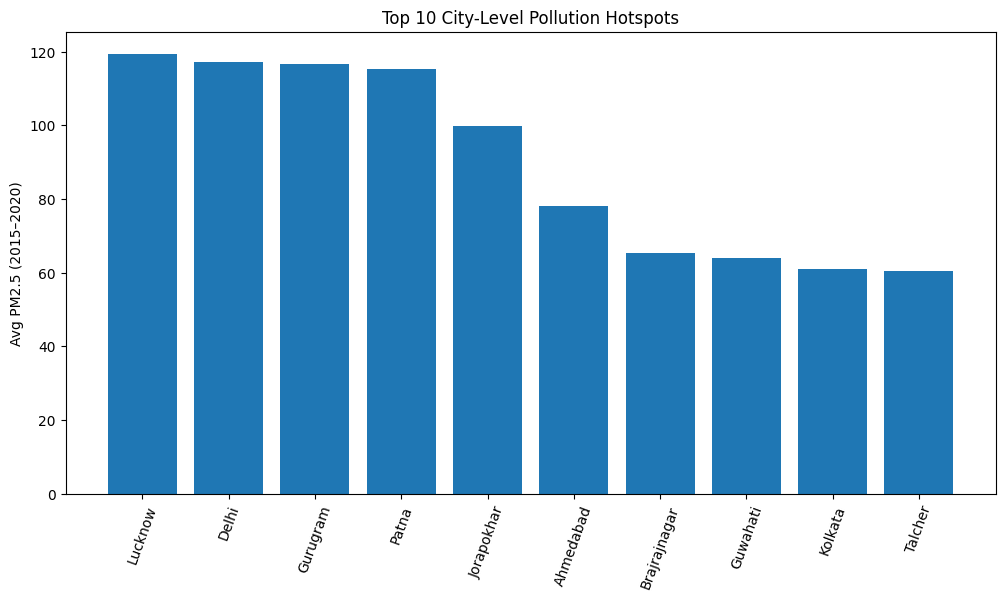

In [ ]:
# CITY-LEVEL HIGH POLLUTION ZONES
# Add YEAR
city["YEAR"] = city["Date"].dt.year

# 5-year city average PM2.5
city_hotspots = (
    city.groupby("City")["PM2_5"]
    .mean()
    .reset_index()
    .sort_values("PM2_5", ascending=False)
)

# Top 10 polluted cities
top10_cities = city_hotspots.head(10)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top10_cities["City"], top10_cities["PM2_5"])
plt.xticks(rotation=70)
plt.ylabel("Avg PM2.5 (2015–2020)")
plt.title("Top 10 City-Level Pollution Hotspots")
plt.show()


In [ ]:
station_day.columns

Index(['StationId', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket',
       'Datetime'],
      dtype='object')

In [ ]:
# STATION-LEVEL HIGH POLLUTION ZONES
# Merge metadata
station_day = station_day.merge(
    stations, on="StationId", how="left"
)

# Station-level PM2.5 average
station_hotspots = (
    station_day.groupby(["StationId", "StationName", "City"])["PM2.5"]
    .mean()
    .reset_index()
    .sort_values("PM2.5", ascending=False)
)

top20_stations = station_hotspots.head(20)
top20_stations


,StationId,StationName,City,PM2.5
11,DL002,"Anand Vihar, Delhi - DPCC",Delhi,153.362717
102,UP016,"Talkatora District Industries Center, Lucknow ...",Lucknow,134.775720
17,DL008,"DTU, Delhi - CPCB",Delhi,131.411982
5,BR007,"IGSC Planetarium Complex, Patna - BSPCB",Patna,131.149685
24,DL015,"Jahangirpuri, Delhi - DPCC",Delhi,128.203178
47,DL038,"Wazirpur, Delhi - DPCC",Delhi,127.626496
41,DL032,"Rohini, Delhi - DPCC",Delhi,122.814418
29,DL020,"Mundka, Delhi - DPCC",Delhi,122.532655
14,DL005,"Bawana, Delhi - DPCC",Delhi,121.249363
15,DL006,"Burari Crossing, Delhi - IMD",Delhi,120.628731


Q2-Identify seasonal spikes, festival effects (e.g.,
Diwali),
crop-burning
meteorological influences where possible.

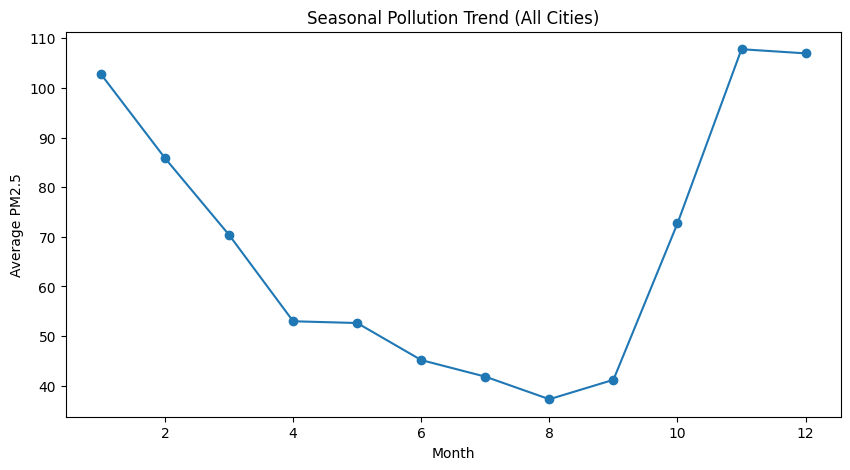

In [ ]:
city["Month"] = city["Date"].dt.month

monthly_trend = (
    city.groupby("Month")["PM2_5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.plot(monthly_trend["Month"], monthly_trend["PM2_5"], marker="o")
plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Seasonal Pollution Trend (All Cities)")
plt.show()


Interpretation

Nov–Jan → Winter spike

Jul–Sep → Monsoon dip

Oct–Nov → Crop burning

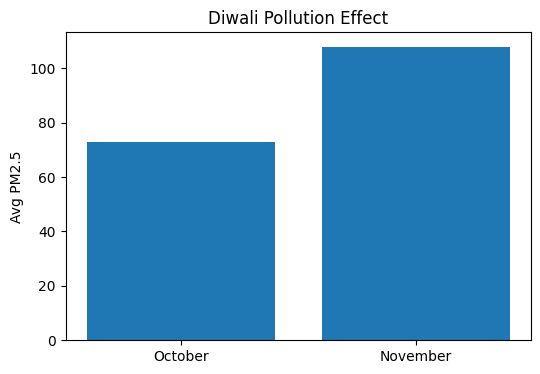

In [ ]:
diwali_effect = (
    city[city["Month"].isin([10,11])]
    .groupby("Month")["PM2_5"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))
plt.bar(diwali_effect["Month"], diwali_effect["PM2_5"])
plt.xticks([10,11], ["October", "November"])
plt.ylabel("Avg PM2.5")
plt.title("Diwali Pollution Effect")
plt.show()


In [ ]:
ncr_cities = ["Delhi", "Gurugram", "Noida", "Ghaziabad", "Faridabad"]

crop_burning = (
    city[
        (city["City"].isin(ncr_cities)) &
        (city["Month"].isin([10,11]))
    ]
    .groupby(["City", "Month"])["PM2_5"]
    .mean()
    .reset_index()
)

crop_burning


,City,Month,PM2_5
0,Delhi,10,140.911935
1,Delhi,11,238.245200
2,Gurugram,10,125.905242
3,Gurugram,11,188.164222


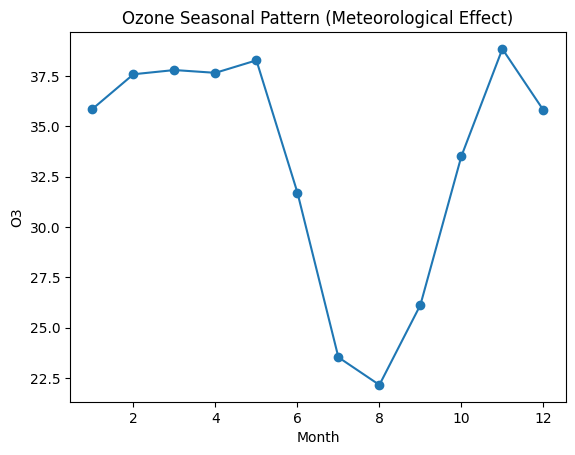

In [ ]:
ozone_trend = (
    city.groupby("Month")["O3"]
    .mean()
    .reset_index()
)

plt.plot(ozone_trend["Month"], ozone_trend["O3"], marker="o")
plt.title("Ozone Seasonal Pattern (Meteorological Effect)")
plt.xlabel("Month")
plt.ylabel("O3")
plt.show()


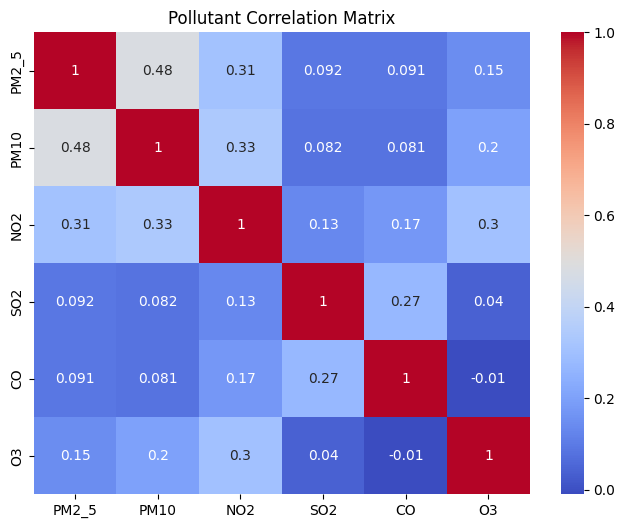

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pollutants = ["PM2_5", "PM10", "NO2", "SO2", "CO", "O3"]

corr_matrix = city[pollutants].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Pollutant Correlation Matrix")
plt.show()


Interpretation

PM2.5 ↔ PM10 (High correlation)
→ Dust + combustion sources

NO2 ↔ CO (High correlation)
→ Vehicular emissions

SO2 weakly correlated with others
→ Independent industrial sources

O3 negative / weak correlation with PM
→ Seasonal + sunlight driven

In [ ]:
city_profile = (
    city.groupby("City")[pollutants]
    .mean()
    .reset_index()
)

city_profile.head()


,City,PM2_5,PM10,NO2,SO2,CO,O3
0,Ahmedabad,78.162260,136.079821,48.760473,51.647576,32.926710,37.046583
1,Aizawl,16.848584,23.272257,0.388496,7.378053,0.283628,3.525664
2,Amaravati,36.585363,74.198617,21.793601,14.367350,0.605405,37.705426
3,Amritsar,54.246560,116.650192,18.889779,8.635008,0.555299,22.883387
4,Bengaluru,36.505082,83.832437,27.971610,5.511672,1.839609,33.412135


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(city_profile[pollutants])


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
city_profile["CLUSTER"] = kmeans.fit_predict(X_scaled)

city_profile[["City", "CLUSTER"]].head()


,City,CLUSTER
0,Ahmedabad,2
1,Aizawl,0
2,Amaravati,0
3,Amritsar,1
4,Bengaluru,0


In [ ]:
cluster_summary = city_profile.groupby("CLUSTER")[pollutants].mean()
cluster_summary


,PM2_5,PM10,NO2,SO2,CO,O3
CLUSTER,,,,,,
0,34.856562,63.114873,16.717921,8.222980,0.865267,27.453525
1,58.190171,115.421011,14.724382,26.081112,1.081980,21.114181
2,78.162260,136.079821,48.760473,51.647576,32.926710,37.046583
3,90.442045,129.854412,35.491875,12.960739,1.320587,42.206781


In [ ]:
vehicular_stations = (
    station_day.groupby("StationId")[["NO2", "CO"]]
    .mean()
    .reset_index()
    .sort_values(["NO2", "CO"], ascending=False)
)

vehicular_stations.head(10)


,StationId,NO2,CO
11,DL002,88.387054,2.203613
37,DL028,72.633517,1.426072
7,BR009,66.838230,0.931257
24,DL015,65.855295,1.654237
25,DL016,63.358558,1.629220
40,DL031,62.903084,1.706773
38,DL029,59.759588,1.510258
48,GJ001,59.025496,22.193407
43,DL034,58.878879,1.610689
27,DL018,58.769295,1.466560


Interpretation

Stations near:

highways

traffic junctions

metro cities

→ Vehicular pollution dominant

In [ ]:
industrial_stations = (
    station_day.groupby("StationId")["SO2"]
    .mean()
    .reset_index()
    .sort_values("SO2", ascending=False)
)

industrial_stations.head(10)


,StationId,SO2
48,GJ001,55.253733
53,JH001,33.645183
82,OD002,28.494789
5,BR007,23.159508
40,DL031,20.548315
37,DL028,19.962430
10,DL001,19.852850
18,DL009,19.037403
68,MH005,18.484557
11,DL002,18.422440


In [ ]:
city["Month"] = city["Date"].dt.month

seasonal_profile = (
    city.groupby("Month")[pollutants]
    .mean()
    .reset_index()
)

seasonal_profile


,Month,PM2_5,PM10,NO2,SO2,CO,O3
0,1,102.755610,139.073619,34.209752,20.800392,3.530608,35.859426
1,2,85.832644,126.386783,32.773684,20.839890,3.567908,37.582035
2,3,70.371274,107.045452,26.728838,20.051200,3.036146,37.791552
3,4,52.979767,98.254488,23.598209,18.415000,2.668572,37.652676
4,5,52.625765,97.678282,22.272570,17.461048,2.564472,38.273625
5,6,45.157274,88.620301,20.993484,15.849952,2.791317,31.708984
6,7,41.822298,79.533310,20.680480,16.238689,3.932619,23.525988
7,8,37.272001,77.294937,20.012886,16.716038,4.302202,22.153721
8,9,41.181530,80.712244,22.616982,16.844116,4.126279,26.123028
9,10,72.684692,112.172114,31.407369,20.690368,4.408793,33.509952


Interpretation

Nov–Jan → PM2.5 spike (winter inversion)

Jul–Sep → PM lowest (rain washout)

Apr–Jun → O3 peak (sunlight chemistry)

In [ ]:
#STATION
# Ensure DATE is datetime
station_day["Date"] = pd.to_datetime(station_day["Date"])

station_coverage = (
    station_day.groupby("StationId")["Date"]
    .agg(start_date="min", end_date="max", total_days="count")
    .reset_index()
)

station_coverage["coverage_years"] = (
    (station_coverage["end_date"] - station_coverage["start_date"]).dt.days / 365
)

station_coverage.sort_values("coverage_years").head(10)


,StationId,start_date,end_date,total_days,coverage_years
80,MZ001,2020-03-11,2020-07-01,113,0.306849
51,HR013,2020-03-05,2020-07-01,119,0.323288
50,HR012,2020-03-05,2020-07-01,119,0.323288
4,BR006,2020-03-03,2020-07-01,121,0.328767
3,BR005,2020-02-27,2020-07-01,126,0.342466
66,KL007,2020-02-13,2020-07-01,140,0.380822
64,KL002,2020-01-22,2020-07-01,162,0.441096
65,KL004,2020-01-22,2020-07-01,162,0.441096
8,BR010,2019-12-24,2020-07-01,191,0.520548
7,BR009,2019-12-24,2020-07-01,191,0.520548


Interpretation

Stations with <1 year coverage → poor longitudinal monitoring

These create geographical and temporal blind spots

In [ ]:
pollutants = ["PM2.5", "PM10", "NO2", "SO2", "CO", "O3"]

missing_station = (
    station_day.groupby("StationId")[pollutants]
    .apply(lambda x: x.isna().mean())
    .reset_index()
)

missing_station["avg_missing_pct"] = missing_station[pollutants].mean(axis=1)

missing_station.sort_values("avg_missing_pct", ascending=False).head(10)


,StationId,PM2.5,PM10,NO2,SO2,CO,O3,avg_missing_pct
20,DL011,1.000000,1.000000,0.381842,0.381842,1.000000,0.388925,0.692101
17,DL008,0.515182,0.592334,0.474863,0.598308,0.597312,0.546541,0.554090
22,DL013,0.350423,1.000000,0.352912,0.351916,0.170732,1.000000,0.537664
68,MH005,0.629667,0.646590,0.640119,0.623196,0.018417,0.620707,0.529783
62,KA010,1.000000,0.327251,0.313714,0.320188,0.056504,1.000000,0.502943
16,DL007,0.402688,0.403186,0.405674,1.000000,0.383275,0.404181,0.499834
42,DL033,0.464908,1.000000,0.425087,0.425087,0.067198,0.431060,0.468890
95,TN003,0.280737,1.000000,0.245396,0.237432,0.048283,1.000000,0.468641
23,DL014,0.511211,0.420528,0.379671,0.495267,0.524165,0.480319,0.468527
57,KA005,1.000000,0.212854,0.191038,0.201061,0.123231,1.000000,0.454697


Interpretation

Stations with >40–50% missing data are unreliable

Indicates sensor failure or poor maintenance

In [ ]:
SAFE_PM25 = 25

city["high_exposure"] = city["PM2_5"] > SAFE_PM25

exposure_days = (
    city.groupby("City")["high_exposure"]
    .sum()
    .reset_index(name="high_pollution_days")
)
intensity = (
    city.groupby("City")["PM2_5"]
    .mean()
    .reset_index(name="avg_PM25")
)
from sklearn.preprocessing import MinMaxScaler

risk_df = exposure_days.merge(intensity, on="City")

scaler = MinMaxScaler()
risk_df[["norm_days", "norm_pm25"]] = scaler.fit_transform(
    risk_df[["high_pollution_days", "avg_PM25"]]
)

risk_df["risk_score"] = (
    0.6 * risk_df["norm_pm25"] +
    0.4 * risk_df["norm_days"]
)

risk_df = risk_df.sort_values("risk_score", ascending=False)
risk_df.head(10)


,City,high_pollution_days,avg_PM25,norm_days,norm_pm25,risk_score
19,Lucknow,1927,119.419214,0.985930,1.000000,0.994372
10,Delhi,1954,117.103559,1.000000,0.977424,0.986454
21,Patna,1776,115.321636,0.907243,0.960051,0.938928
12,Gurugram,1623,116.561188,0.827514,0.972136,0.914287
0,Ahmedabad,1928,78.162260,0.986451,0.597770,0.753243
16,Jorapokhar,1082,99.811976,0.545597,0.808842,0.703544
8,Chennai,1811,52.520981,0.925482,0.347784,0.578863
14,Hyderabad,1536,46.523402,0.782178,0.289311,0.486458
6,Brajrajnagar,805,65.298737,0.401251,0.472359,0.443916
15,Jaipur,1040,54.370628,0.523710,0.365817,0.428974


Interpretation

Cities with both high PM2.5 and long exposure rank highest

NCR cities dominate top risk

Coastal / hill cities show lower risk

In [ ]:
city["Month"] = city["Date"].dt.month

winter_pm = (
    city[city["Month"].isin([11, 12, 1, 2])]
    .groupby("City")["PM2_5"]
    .mean()
    .reset_index(name="winter_PM25")
)
vulnerability = risk_df.merge(winter_pm, on="City")

vulnerability = vulnerability.sort_values(
    ["risk_score", "winter_PM25"], ascending=False
)

vulnerability.head(10)


,City,high_pollution_days,avg_PM25,norm_days,norm_pm25,risk_score,winter_PM25
0,Lucknow,1927,119.419214,0.985930,1.000000,0.994372,195.357327
1,Delhi,1954,117.103559,1.000000,0.977424,0.986454,194.947670
2,Patna,1776,115.321636,0.907243,0.960051,0.938928,207.201262
3,Gurugram,1623,116.561188,0.827514,0.972136,0.914287,149.326042
4,Ahmedabad,1928,78.162260,0.986451,0.597770,0.753243,100.658119
5,Jorapokhar,1082,99.811976,0.545597,0.808842,0.703544,121.512064
6,Chennai,1811,52.520981,0.925482,0.347784,0.578863,59.006556
7,Hyderabad,1536,46.523402,0.782178,0.289311,0.486458,61.516724
8,Brajrajnagar,805,65.298737,0.401251,0.472359,0.443916,89.233077
9,Jaipur,1040,54.370628,0.523710,0.365817,0.428974,69.822992


# **Vulnerability Interpretation **

Cities most vulnerable:

Long winters

Persistent PM2.5

Dense population exposure

High-risk groups affected most:

School children

Elderly

Daily wage / traffic workers

In [ ]:
city["YEAR"] = city["Date"].dt.year

yearly_pm = (
    city.groupby(["City", "YEAR"])["PM2_5"]
    .mean()
    .reset_index()
)
yearly_pm["yoy_change"] = (
    yearly_pm.groupby("City")["PM2_5"]
    .diff()
)
worst_deterioration = (
    yearly_pm.sort_values("yoy_change", ascending=False)
    .dropna()
    .head(10)
)

worst_deterioration


,City,YEAR,PM2_5,yoy_change
45,Gurugram,2016,127.195994,85.129679
63,Jorapokhar,2018,169.125333,78.039000
91,Talcher,2018,70.619316,40.021016
46,Gurugram,2017,160.380425,33.184430
2,Ahmedabad,2017,105.563496,23.740968
38,Delhi,2016,138.502842,21.162020
83,Patna,2016,134.628552,17.382617
51,Guwahati,2020,74.530219,16.726833
26,Brajrajnagar,2020,73.109372,15.092317
16,Bengaluru,2016,46.522090,14.528734


In [ ]:
best_improvement = (
    yearly_pm.sort_values("yoy_change")
    .dropna()
    .head(10)
)

best_improvement


,City,YEAR,PM2_5,yoy_change
64,Jorapokhar,2019,59.561526,-109.563807
8,Amaravati,2018,37.663836,-46.342217
47,Gurugram,2018,116.738644,-43.641781
87,Patna,2020,61.321694,-42.886114
71,Lucknow,2016,119.449508,-39.880958
28,Chandigarh,2020,27.696612,-32.984380
3,Ahmedabad,2018,74.719082,-30.844413
24,Brajrajnagar,2018,66.590020,-28.994687
22,Bhopal,2020,38.887869,-28.400622
42,Delhi,2020,80.317978,-28.183501


# **Interpretation **

**Deterioration drivers:**

Rapid urbanization

Increased traffic

Crop burning spillover

Industrial expansion

**Improvement drivers:**

Policy interventions

Cleaner fuel adoption

Lockdown / traffic regulation

Meteorological variation